# Reinforcement Learning

### Cliff Environment

The environment used is Cliff:

![Cliff](images/cliff.png)

The agent starts in cell $(3, 0)$ and has to reach the goal in $(3, 11)$. Falling from the cliff resets the position to the start state (the episode ends only when the goal state is reached). All other cells are safe. Action dinamycs is deterministic, meaning that the agent always reaches the desired next state.

In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('../tools'))
if module_path not in sys.path:
    sys.path.append(module_path)

import gym, envs
from utils.ai_lab_functions import *
from timeit import default_timer as timer
from tqdm import tqdm as tqdm

env = gym.make("Cliff-v0")
env.render()

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T



The cell types are the following:

- x - Start position
- o - Safe
- C - Cliff
- T - Goal

Rewards:

- -1 for each "safe" cell (o)
- -100 for falling from the cliff (C)

In addition to the functionalities of the environments you have been using in the previous sessions, there are also a few more:

- step(action): the agent **execute action in the environment** from the current state. Returns a tuple (new_state, reward, done, info) where:
    - new_state: is the new state reached as a consequence of the agent's last action
    - reward: the reward obtained by the agent
    - done: True if the episode has ended, False otherwise
    - info: not used, you can safely discard it

- reset(): the environment is reset and the agent goes back to the starting position. Returns the initial state id

In [2]:
state = env.reset()
action = 0 # Go UP
new_state, reward, done, _ = env.step(0)

print("State: {} \nAction: {} \nNew State: {} \nReward: {} \nDone: {}".format(env.state_to_pos(state), action, env.state_to_pos(new_state), reward, done))

State: (np.int64(3), np.int64(0)) 
Action: 0 
New State: (np.int64(2), np.int64(0)) 
Reward: -1 
Done: False


Suppose we want to execute a random policy in the environment: we create such policy as usual, we reset the environment to its initial state and also set a maximum number of steps for the episod. Then we execute a loop where at each iteration a step is performed by using the action prescribed by the policy.

In [3]:
policy = np.random.choice(env.action_space.n, env.observation_space.n)
state = env.reset()
ep_limit = 20 #maximum number of steps the policy will execute

el = 0 #initialize counter to accumulate the number of steps the policy execute (episode length)
total_reward = 0 #initialize accumulate to sum the rewards received at each step 

# Episode execution loop
for _ in range(ep_limit):
    next_state, reward, done, _ = env.step(policy[state])  # Execute a step
    total_reward += reward
    el += 1
    if done or el == ep_limit:  # If done == True, the episode has ended
        break
    state = next_state
    
print("Policy: \n {} \n Total Reward of Random Policy: : {} \n Episode Length {} ".format(policy.reshape(4,12),total_reward,el))

Policy: 
 [[1 0 2 0 3 0 1 0 1 2 0 3]
 [1 2 1 2 1 3 2 0 2 0 1 1]
 [3 0 3 2 2 2 3 0 3 2 0 0]
 [2 1 3 2 2 1 3 3 3 0 1 3]] 
 Total Reward of Random Policy: : -20 
 Episode Length 20 


### Q-Learning

In [4]:
def epsilon_greedy(q, state, epsilon):
    if np.random.random() < epsilon: #enters the if only if the random number is less than epsilon (i.e., with probability  epsilon)
        return np.random.choice(q.shape[1]) #the size of first dimension of q is number of states, the second is number of actions 
    return q[state].argmax() #q[state] is a vector of q-values indexed by actions

def softmax(q, state, temp):
    e = np.exp(q[state] / temp) #a vector indexed by action where each value is e^(q(s,a)/T)
    return np.random.choice(q.shape[1], p=e / e.sum()) # choose an action with probability e^(q(s,a)/T)/sum_{a'} e^(q(s,a')/T)  

In [5]:
def q_learning(environment, episodes, alpha, gamma, expl_func, expl_param):
    q = np.zeros((environment.observation_space.n, environment.action_space.n))  # Q(s, a)
    rews = np.zeros(episodes)
    lengths = np.zeros(episodes)
    
    for i in range(episodes):
        state = environment.reset()
        is_terminal = False
        while not is_terminal:
            action = expl_func(q, state, expl_param)
            next_state, reward, is_terminal, info = environment.step(action)
            
            q[state, action] += alpha * (reward + gamma * max(q[next_state]) - q[state, action])
            
            rews[i] += reward
            lengths[i] += 1
            state = next_state
    
    policy = q.argmax(axis=1) # q.argmax(axis=1) automatically extract the policy from the q table
    return policy, rews, lengths

In [6]:
env_name = "Cliff-v0"
env = gym.make(env_name)
env.render()
print()

# Learning parameters
episodes = 500
alpha = .3
gamma = .9
epsilon = .1

t = timer()

# Q-Learning epsilon greedy
policy, rewards, lengths = q_learning(env, episodes, alpha, gamma, epsilon_greedy, epsilon)
print(f"Execution time: {round(timer() - t, 4)}s") 
policy_render = np.vectorize(env.actions.get)(policy.reshape(env.shape))
_ = run_episode(env, policy, 20)

results = CheckResult_L5(policy_render)
results.check_qlearning()

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Execution time: 0.2638s

#####################################################
#######  Environment: Cliff-v0 	Q-Learning  #########
#####################################################

===> Your policy:

[['U' 'U' 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'D']
 ['D' 'D' 'R' 'R' 'R' 'R' 'D' 'R' 'R' 'R' 'R' 'D']
 ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D']
 ['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U']]

===> Our policy:

[['D' 'U' 'D' 'R' 'D' 'R' 'D' 'D' 'L' 'D' 'D' 'D']
 ['D' 'U' 'R' 'R' 'R' 'U' 'D' 'R' 'D' 'R' 'R' 'D']
 ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D']
 ['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U']]


### SARSA

In [7]:
def sarsa(environment, episodes, alpha, gamma, expl_func, expl_param):
    q = np.zeros((environment.observation_space.n, environment.action_space.n))  # Q(s, a)
    rews = np.zeros(episodes)
    lengths = np.zeros(episodes)
    
    for i in range(episodes):
        state = environment.reset()
        action = expl_func(q, state, expl_param)
        is_terminal = False
        while not is_terminal:
            next_state, reward, is_terminal, info = environment.step(action)
            next_action = expl_func(q, next_state, expl_param)
            
            q[state, action] += alpha * (reward + gamma * q[next_state, next_action] - q[state, action])
            
            rews[i] += reward
            lengths[i] += 1
            state = next_state
            action =next_action
    
    policy = q.argmax(axis=1) # q.argmax(axis=1) automatically extract the policy from the q table
    return policy, rews, lengths

In [8]:
env_name = "Cliff-v0"
env = gym.make(env_name)
env.render()
print()

# Learning parameters
episodes = 500
alpha = .3
gamma = .9
epsilon = .1

t = timer()

# SARSA epsilon greedy
policy, rews, lengths = sarsa(env, episodes, alpha, gamma, epsilon_greedy, epsilon)
print(f"Execution time: {round(timer() - t, 4)}s") 
_ = run_episode(env, policy, 20)
policy_render = np.vectorize(env.actions.get)(policy.reshape(env.shape))


results = CheckResult_L5(policy_render)
results.check_sarsa()

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


Execution time: 0.2307s

################################################
#######  Environment: Cliff-v0 	SARSA  #########
################################################

===> Your policy:

[['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D' 'D']
 ['U' 'L' 'U' 'U' 'R' 'U' 'U' 'U' 'U' 'R' 'R' 'D']
 ['U' 'U' 'L' 'U' 'U' 'U' 'L' 'U' 'U' 'R' 'R' 'D']
 ['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U']]

===> Our policy:

[['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'D']
 ['U' 'U' 'L' 'U' 'U' 'U' 'R' 'R' 'U' 'U' 'R' 'D']
 ['U' 'U' 'L' 'U' 'R' 'R' 'L' 'R' 'U' 'U' 'R' 'D']
 ['U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U' 'U']]


### Comparison


###########################################################
################ Environment: Cliff-v0 ####################
###########################################################

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T

Execution time: 0.5112s


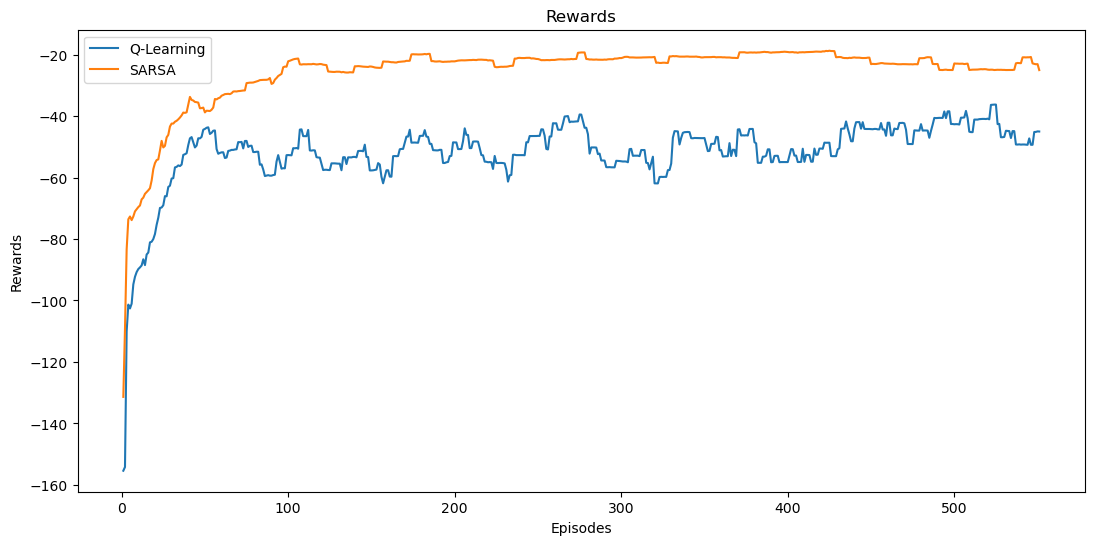

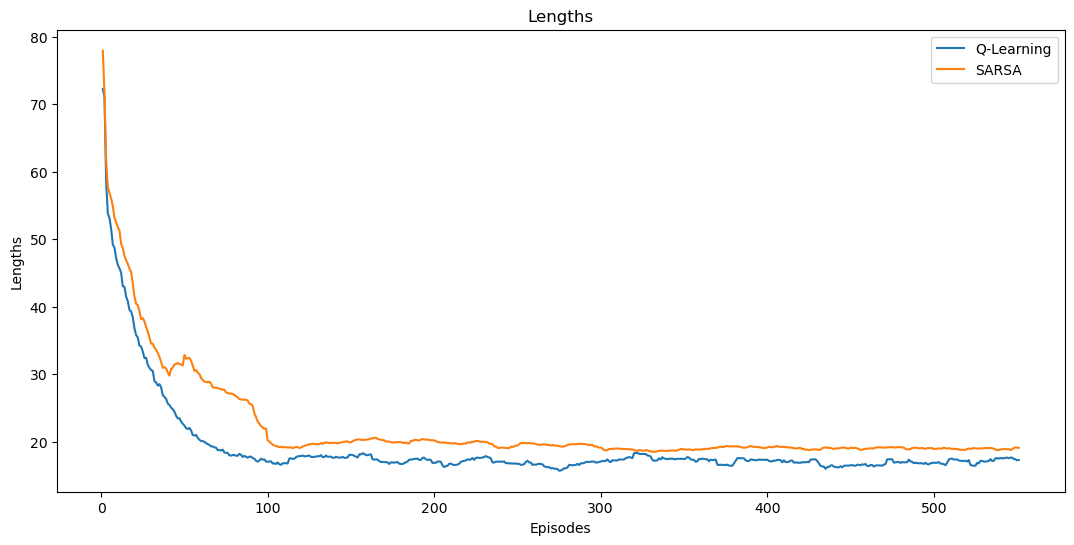

In [9]:
envname = "Cliff-v0"
print()
print("###########################################################")
print("################ Environment: Cliff-v0 ####################")
print("###########################################################\n")

env = gym.make(envname)
env.render()

# Learning parameters
episodes = 600
ep_limit = 50
alpha = .3
gamma = .9
epsilon = .1
temp = 1

rewser = []
lenser = []

litres = np.arange(1, episodes + 1)  # Learning iteration values
window = 50  # Rolling window

t = timer()

# Q-Learning
_, rews, lengths = q_learning(env, episodes, alpha, gamma, epsilon_greedy, epsilon)
#_, rews, lengths = q_learning(env, episodes, alpha, gamma, softmax, temp)
rews = rolling(rews, window)
rewser.append({"x": np.arange(1, len(rews) + 1), "y": rews, "ls": "-", "label": "Q-Learning"})
lengths = rolling(lengths, window)
lenser.append({"x": np.arange(1, len(lengths) + 1), "y": lengths, "ls": "-", "label": "Q-Learning"})

# SARSA
_, rews, lengths = sarsa(env, episodes, alpha, gamma, epsilon_greedy, epsilon)
#_, rews, lengths = q_learning(env, episodes, alpha, gamma, softmax, temp)
rews = rolling(rews, window)
rewser.append({"x": np.arange(1, len(rews) + 1), "y": rews, "label": "SARSA"})
lengths = rolling(lengths, window)
lenser.append({"x": np.arange(1, len(lengths) + 1), "y": lengths, "label": "SARSA"})

print("Execution time: {0}s".format(round(timer() - t, 4)))

plot(rewser, "Rewards", "Episodes", "Rewards")
plot(lenser, "Lengths", "Episodes", "Lengths")